<a href="https://colab.research.google.com/github/drscicomm/food-security/blob/main/Tigray_BERTopic_Stage_3_Temp_Ceasefire_20241023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BERTopic FAQ: https://maartengr.github.io/BERTopic/faq.html#i-have-only-a-few-topics-how-do-i-increase-them

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
output_path = '/content/gdrive/MyDrive/Tigray 20241009'

In [2]:
# Step 1: Install Dependencies
!pip install bertopic
!pip install umap-learn
!pip install calplot


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.8/255.8 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for calplot: filename=calplot-0.1.7.5-py3-none-any.whl size=8116 sha256=17dea7ab61d5879c14207ce9565b02336c28937488bfd42bce90b18866190d82
  Stored in directory: /root/.cache/pip/wheels/77/75/32/a518a4a1421776a93e1ede33cb8dac474095bf31fed7e4e22c
Successfully built calplot


In [ ]:
#from google.colab import files
#uploaded = files.upload()

In [3]:
# Step 2: Import Libraries
import pandas as pd
import re
from bertopic import BERTopic
from sklearn.feature_extraction.text import TfidfVectorizer
from umap import UMAP
import calplot
import matplotlib.pyplot as plt
from hdbscan import HDBSCAN  # Make sure you have the library installed
from umap import UMAP

In [22]:
# Load the dataset (replace 'your_file.xlsx' with the actual file name)
tweets_data = pd.read_csv('/content/Stage 3_more filtered_food_security_tweetscsv.csv')

In [23]:
#checking info
tweets_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37245 entries, 0 to 37244
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   created_at  37245 non-null  object
 1   tweet       37245 non-null  object
dtypes: object(2)
memory usage: 582.1+ KB


In [24]:
# Combined function for cleaning tweets and removing short words
def enhanced_clean_tweet(tweet):
    tweet = re.sub(r'@\w+|#\w+|http\S+', '', tweet)  # Remove mentions, hashtags, links
    tweet = re.sub(r'[^\w\s]', '', tweet)  # Remove special characters
    tweet = re.sub(r'\b\w{1,2}\b', '', tweet)  # Remove short words (1-2 characters)
    tweet = re.sub(r'\s+', ' ', tweet)  # Collapse multiple spaces into one
    tweet = tweet.strip().lower()  # Lowercase and strip any extra spaces
    return tweet

# Apply the enhanced cleaning to the dataset
tweets_data['cleaned_tweet'] = tweets_data['tweet'].astype(str).apply(enhanced_clean_tweet)

# Prepare the cleaned text for BERTopic without removing duplicates
tweets_cleaned = tweets_data['cleaned_tweet'].tolist()

# Verify the number of cleaned tweets after enhanced cleaning
print(f"Number of cleaned tweets after enhanced cleaning: {len(tweets_cleaned)}")



Number of cleaned tweets after enhanced cleaning: 37245


In [6]:
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Some notes on the following parameters
1. TF-IDF Vectorizer:
stop_words=stop_words: Using a custom stop word list helps eliminate irrelevant terms, allowing the model to focus on meaningful words.
max_df=0.75: This ensures that words appearing in more than 75% of the documents (tweets) are ignored. This is a conservative setting, removing common words but still retaining some context.
min_df=2: This removes words that appear in fewer than 2 documents. It’s a semi-conservative setting, ensuring rare words aren’t treated as important, but it's not too aggressive (e.g., min_df=5 would be more aggressive).
Effect: These TF-IDF settings filter out both overly common and very rare words, which reduces noise without being too aggressive.

2. UMAP Parameters:
n_neighbors=5: This controls how local or global the structure of the data should be when reducing dimensionality. With n_neighbors=5, UMAP emphasizes local structure, meaning nearby points (tweets) are more likely to be clustered together. This is conservative, as it tries to preserve finer details.
min_dist=0.5: This controls how tightly UMAP clusters points. A min_dist of 0.5 strikes a balance, allowing for some separation between points but still forming reasonably tight clusters.
n_components=2: Reducing to 2 dimensions is common in topic modeling to visualize topics while maintaining reasonable accuracy.
Effect: These UMAP settings focus on preserving local details, which leads to semi-conservative clustering. It won't force topics to merge unless they are genuinely similar, allowing you to retain meaningful distinctions between topics.

In [25]:
stop_words = list(set(stopwords.words("english") + [
    "amp", "pple", "ppls", "man", "wasnt", "doesnt", "said", "appointed" # Domain-specific common words
      # Additional irrelevant terms
]))

In [26]:
# Step 1: Set TF-IDF Vectorizer parameters
tfidf_vectorizer = TfidfVectorizer(stop_words=stop_words, max_df=.85, min_df=3, ngram_range=(1, 2), sublinear_tf=True)

# Step 2: Set UMAP and HDBSCAN parameters
umap_model = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=30, min_samples=10, prediction_data=True)  # Add prediction_data=True


In [27]:
# Step 3: Initialize the BERTopic model with default parameters
topic_model = BERTopic(
    umap_model=umap_model,
    vectorizer_model=tfidf_vectorizer,
    hdbscan_model=hdbscan_model,
    min_topic_size=100  # Ensure there are enough tweets per topic
)

# Step 4: Fit the model on the cleaned tweets
topics, probabilities = topic_model.fit_transform(tweets_cleaned)

In [28]:
# Optional: Visualize the topics
topic_model.visualize_topics()

In [29]:
# Save the topic information, including keywords, probabilities, and representative tweets
# Get topic info (keywords and representative tweets)
topics_info = topic_model.get_topic_info()
topics_keywords = topic_model.get_topics()
representative_tweets = topic_model.get_representative_docs()

In [30]:
# Combine topics info into a DataFrame
df_topics_info = pd.DataFrame(topics_info)

# Save to a CSV file
df_topics_info.to_csv('Stage 3_Original Topic_Info.csv', index=False)

In [31]:
# Save representative tweets (optional)
df_representative_tweets = pd.DataFrame(representative_tweets)
df_representative_tweets.to_csv('Stage 3_Original Representative_Tweets.csv', index=False)

In [32]:
# Assign the topic numbers to the DataFrame
tweets_data['topic_number'] = topics

# Select the columns 'created_at', 'cleaned_tweet', and 'topic_number'
df_final_for_export = tweets_data[['created_at', 'cleaned_tweet', 'topic_number']]


# Save this DataFrame to a CSV file
df_final_for_export.to_csv('Stage 3_Original Tweets_Topic_Assignment.csv', index=False)

print("Topic assignments saved successfully!")


Topic assignments saved successfully!


In [ ]:
# Install wordcloud if not already installed
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Get the new topic info and sort by topic size
new_topic_info = topic_model.get_topic_info()

# Filter out the outlier topic (-1) and get the top 20 topics
top_20_topics = new_topic_info[new_topic_info['Topic'] != -1].head(20)

# Generate and display word clouds for the top 20 topics
for topic in top_20_topics['Topic']:
    # Extract the top words for the topic
    words = dict(topic_model.get_topic(topic))

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(words)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Topic {topic}')
    plt.show()


## Reduce Topic Model (Optional)

In [33]:
# Use only if need to reduce topics

# Reduce the number of topics
topic_model = topic_model.reduce_topics(tweets_cleaned)

# Get the reduced topic assignments for each tweet
reduced_topics = topic_model.transform(tweets_cleaned)[0]  # Topic assignments for each tweet

In [35]:
# Create a DataFrame with the tweet information and reduced topic assignments
df_reduced = pd.DataFrame({
    'created_at': tweets_data['created_at'],  # Using 'created_at' from tweets_data
    'cleaned_tweets': tweets_cleaned,         # The cleaned tweets you used for topic modeling
    'reduced_topic_number': reduced_topics    # The reduced topic numbers assigned to each tweet
})

In [37]:
# Step 5: Get representative tweets for each topic (modifying based on topic size)
topics = topic_model.get_topics()
representative_tweets = []

# Get one representative tweet per topic
for topic_num in topics.keys():
    docs = topic_model.get_representative_docs(topic_num)
    if docs:  # Ensure there are representative docs
        representative_tweets.append(docs[0])  # Take the first representative tweet for each topic

# Create DataFrame for representative tweets
df_representative_tweets = pd.DataFrame({
    'Topic': [f'Topic {i}' for i in range(len(representative_tweets))],
    'Representative_Tweet': representative_tweets
})

# Save representative tweets to CSV
representative_tweet_file_path = '/content/Stage 3_Reduced Representative_Tweets.csv'
df_representative_tweets.to_csv(representative_tweet_file_path, index=False)


In [38]:
# Get topic info and save to CSV
topics_info = topic_model.get_topic_info()
topics_info_file_path = 'topic_info.csv'
topics_info.to_csv(topics_info_file_path, index=False)

In [41]:
import plotly.io as pio  # Ensure this is imported for saving images
import plotly.offline as pyo  # Use this for rendering Plotly figures in non-notebook environments

In [44]:
# Optional: Visualize the topics
topic_model.visualize_topics()

In [ ]:
#  Step 8: Check if all tweets have been assigned a topic
num_unassigned = df_reduced['reduced_topic_number'].isna().sum()
print(f"Number of tweets without an assigned topic: {num_unassigned}")

In [ ]:
print(f"CSV file for reduced topics saved to {output_file_path}")
print(f"CSV file for representative tweets saved to {representative_tweet_file_path}")
print(f"CSV file for topic info saved to {topics_info_file_path}")
print("Inter-topic distance map saved as 'inter_topic_distance.png'")

In [ ]:
# Step 1: Install wordcloud if not already installed
!pip install wordcloud

# Step 2: Generate and display word clouds for each topic
for topic in new_topic_info['Topic']:
    if topic == -1:  # Skip the outlier topic (-1)
        continue

    # Extract the top words for the topic
    words = dict(topic_model.get_topic(topic))

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(words)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Topic {topic}')
    plt.show()

## Alterative Heatmap - assuming already ran BERTopic

Offline, I analyzed the ~600 original topics. I combined similar topics. I am uploading the file here "Stage 1 tweets with new topic assignments..."
See Word doc to see how I mapped topics to categories.

In [1]:
#Make sure you have these
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
# Load the correct CSV file generated earlier
file_path = '/content/Final_Updated_Tweets_Topic_Assignment.csv'
df_new_tweets = pd.read_csv(file_path)

# Ensure 'date' column is in datetime format
df_new_tweets['created_at'] = pd.to_datetime(df_new_tweets['created_at'])


In [15]:
# Now, check the shape and first few rows
df_new_tweets_shape = df_new_tweets.shape
df_new_tweets_head = df_new_tweets.head()

In [16]:
print(df_new_tweets_shape)
print(df_new_tweets_head)

(37245, 4)
                 created_at  \
0 2021-06-29 22:45:28+00:00   
1 2021-06-29 22:45:53+00:00   
2 2021-06-29 22:46:15+00:00   
3 2021-06-29 22:46:25+00:00   
4 2021-06-29 22:47:39+00:00   

                                       cleaned_tweet  topic_number  \
0  the head the agency for international developm...           470   
1  ethiopian government has blocked critical aid ...           287   
2  the head the agency for international developm...           470   
3  still reluctant condemn despite mounting evide...            -1   
4  still reluctant condemn despite mounting evide...            -1   

   category_name  
0            9.0  
1            4.0  
2            9.0  
3            2.0  
4            2.0  


In [17]:
# Check the column names in the DataFrame
print(df_new_tweets.columns)


Index(['created_at', 'cleaned_tweet', 'topic_number', 'category_name'], dtype='object')


In [18]:
# Group by date and topic to get tweet volume per day per topic
# We will need to group by date and topic (which are now new topic numbers 0-12)
tweets_per_day = df_new_tweets.groupby([df_new_tweets['created_at'].dt.date, 'category_name']).size().unstack(fill_value=0)

# Apply rolling average and normalize the data
rolling_window_length = 7  # Weekly rolling window

# Normalize each column and apply a rolling average
for col in tweets_per_day.columns:
    max_value = tweets_per_day[col].max()
    tweets_per_day[col] = (tweets_per_day[col] / max_value) * 100  # Normalize to percentage
    tweets_per_day[col] = tweets_per_day[col].rolling(window=rolling_window_length).mean()

In [19]:
# Map topic IDs to new custom topic names (ordered from highest to lowest volume)
custom_labels = {
    5: "Aid Disruptions and Violence",  # 3505 tweets
    0: "Nile Dam Dispute and Water Scarcity",  # 2860 tweets
    4: "Economic Impact and Pressures",  # 3143 tweets
    6: "Religious and Ethnic Conflicts",  # 1407 tweets
    8: "Political Tensions and Elections",  # 2512 tweets
    2: "Famine, Crisis Recovery, and Food Aid",  # 4657 tweets
    9: "COVID-19 Aid, Health, and Case Response",  # 2587 tweets
    7: "Agricultural Sector and Crop Production",  # 2695 tweets
    3: "Food Security, Hunger Relief, and Innovations",  # 5212 tweets
    12: "Food Supply Chains and Local Markets",  # 84 tweets
    10: "Irrigation and Water Projects",  # 1667 tweets
    11: "Climate Change and Environmental Impact",  # 1896 tweets
    13: "Ethnic Conflict and Agriculture",  # 1965 tweets
    1: "Locust Plagues and Agriculture",  # 775 tweets
    14: "General Conflict Commentary",  # 1276 tweets
}


# Replace topic numbers with custom names in the DataFrame
tweets_per_day.columns = tweets_per_day.columns.map(custom_labels)

In [20]:
print(tweets_per_day.shape)

(421, 15)


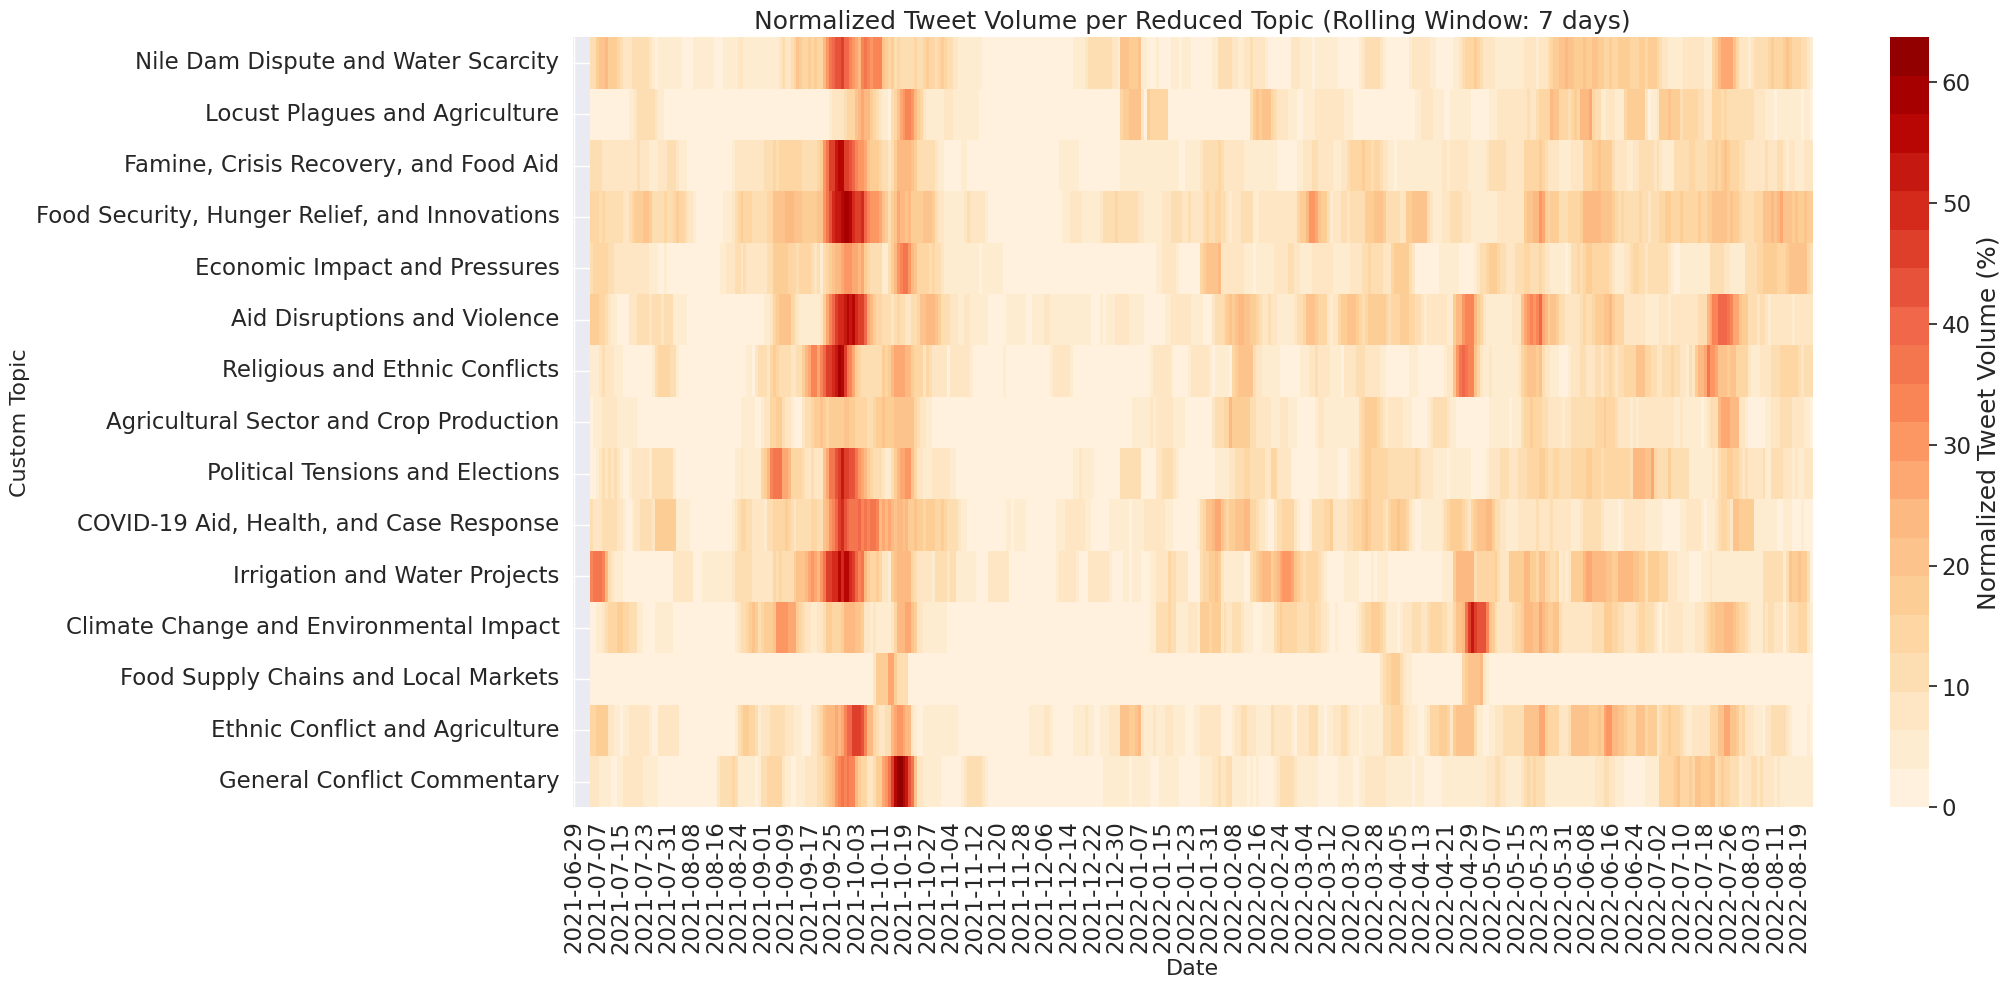

In [21]:
# Generate the heatmap
sns.set(font_scale=1.5)
fig = plt.figure(figsize=(20, 10))

# Create the heatmap
sns.heatmap(tweets_per_day.T, cmap=sns.color_palette("OrRd", 20), cbar_kws={'label': 'Normalized Tweet Volume (%)'})

plt.title(f"Normalized Tweet Volume per Reduced Topic (Rolling Window: {rolling_window_length} days)", fontsize=18)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Custom Topic", fontsize=16)

# Save the heatmap as an image BEFORE showing it
plt.savefig('/content/Stage 3_Vol Per Topic Per Day_heatmap.png', dpi=300, bbox_inches='tight')

# Show the heatmap
plt.show()

## Alternative sentiment per topic per day

In [22]:
!pip install transformers torch
from transformers import pipeline

In [ ]:
# Optional Load the CSV file with tweets and topics
file_path = '/content/Stage 3_tweets_with_all_new_topic_numbers.csv'
df_new_tweets = pd.read_csv(file_path)

# Ensure 'date' column is in datetime format (optional - may have already done this step)
df_new_tweets['created_at'] = pd.to_datetime(df_new_tweets['created_at'])

In [23]:
# Initialize the BERT sentiment analysis model
sentiment_analysis = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [24]:
# Define the function to get sentiment scores
def get_sentiment_score(text):
    result = sentiment_analysis(text)[0]
    if result['label'] == 'POSITIVE':
        return result['score']  # Positive score from 0 to 1
    else:
        return -result['score']  # Negative score from 0 to -1

# Ensure all values in the 'cleaned_tweet' column are strings
df_new_tweets['cleaned_tweet'] = df_new_tweets['cleaned_tweet'].fillna("").astype(str)

# Apply sentiment analysis to the 'cleaned_tweet' column and create a new 'sentiment_score' column
df_new_tweets['sentiment_score'] = df_new_tweets['cleaned_tweet'].apply(get_sentiment_score)

# Group by date and topic, and calculate the average sentiment per day per topic
df_new_tweets['created_at'] = pd.to_datetime(df_new_tweets['created_at'])  # Ensure the 'created_at' is in datetime format
sentiment_per_day = df_new_tweets.groupby([df_new_tweets['created_at'].dt.date, 'category_name'])['sentiment_score'].mean().unstack(fill_value=0)

# Display the result
print(sentiment_per_day.head())

category_name      0.0   1.0       2.0       3.0       4.0       5.0   \
created_at                                                              
2021-06-29    -0.988024   0.0 -0.794066 -0.992826 -0.988198 -0.549045   
2021-06-30    -0.983290   0.0 -0.974039 -0.791795 -0.984412 -0.295994   
2021-07-01    -0.972901   0.0 -0.797722 -0.826637 -0.380773 -0.948648   
2021-07-02    -0.960549   0.0 -0.755230 -0.797513 -0.984751 -0.994867   
2021-07-03    -0.989584   0.0 -0.685287 -0.908087 -0.988981 -0.793448   

category_name      6.0       7.0       8.0       9.0       10.0      11.0  \
created_at                                                                  
2021-06-29     0.000000  0.000000  0.023899 -0.669262  0.000000  0.000000   
2021-06-30     0.000000 -0.989424 -0.990194 -0.817506  0.000000  0.000000   
2021-07-01     0.000000  0.000000 -0.993906 -0.687522  0.000000  0.000000   
2021-07-02     0.000000 -0.966309 -0.995071 -0.996089 -0.998325 -0.998529   
2021-07-03    -0.997989 -0

In [25]:
# Select the required columns: 'created_at', 'cleaned_tweet', 'new_topic_number', and 'sentiment_score'
df_for_export = df_new_tweets[['created_at', 'cleaned_tweet', 'category_name', 'sentiment_score']]

# Save the final DataFrame to a CSV file
df_for_export.to_csv('Stage_3_Tweets_with_Sentiment_Scores.csv', index=False)

print("Sentiment analysis complete and CSV file saved.")

Sentiment analysis complete and CSV file saved.


In [28]:
# Optional - when Loading the CSV file into a DataFrame for later analysis
file_path = '/content/Stage_3_Tweets_with_Sentiment_Scores.csv'  # Path to the uploaded file
sentiment_data = pd.read_csv(file_path)

In [29]:
# Ensure 'created_at' is in datetime format
sentiment_data['created_at'] = pd.to_datetime(sentiment_data['created_at'])

In [30]:
# Group by date and topic, and calculate the average sentiment per day per topic
sentiment_per_day = sentiment_data.groupby([sentiment_data['created_at'].dt.date, 'category_name'])['sentiment_score'].mean().unstack(fill_value=0)

In [31]:
 #Map topic numbers to custom labels (0-14) in the DataFrame
custom_labels = {
    5: "Aid Disruptions and Violence",  # 3505 tweets
    0: "Nile Dam Dispute and Water Scarcity",  # 2860 tweets
    4: "Economic Impact and Pressures",  # 3143 tweets
    6: "Religious and Ethnic Conflicts",  # 1407 tweets
    8: "Political Tensions and Elections",  # 2512 tweets
    2: "Famine, Crisis Recovery, and Food Aid",  # 4657 tweets
    9: "COVID-19 Aid, Health, and Case Response",  # 2587 tweets
    7: "Agricultural Sector and Crop Production",  # 2695 tweets
    3: "Food Security, Hunger Relief, and Innovations",  # 5212 tweets
    12: "Food Supply Chains and Local Markets",  # 84 tweets
    10: "Irrigation and Water Projects",  # 1667 tweets
    11: "Climate Change and Environmental Impact",  # 1896 tweets
    13: "Ethnic Conflict and Agriculture",  # 1965 tweets
    1: "Locust Plagues and Agriculture",  # 775 tweets
    14: "General Conflict Commentary",  # 1276 tweets
}

Checking unique values in 'category_name' column in the original data:
[ 9.  4.  2. 13.  0.  5.  3.  8. 14.  7. nan 10. 11.  6.  1. 12.]
Unique topics after processing: Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], dtype='int64', name='category_name')


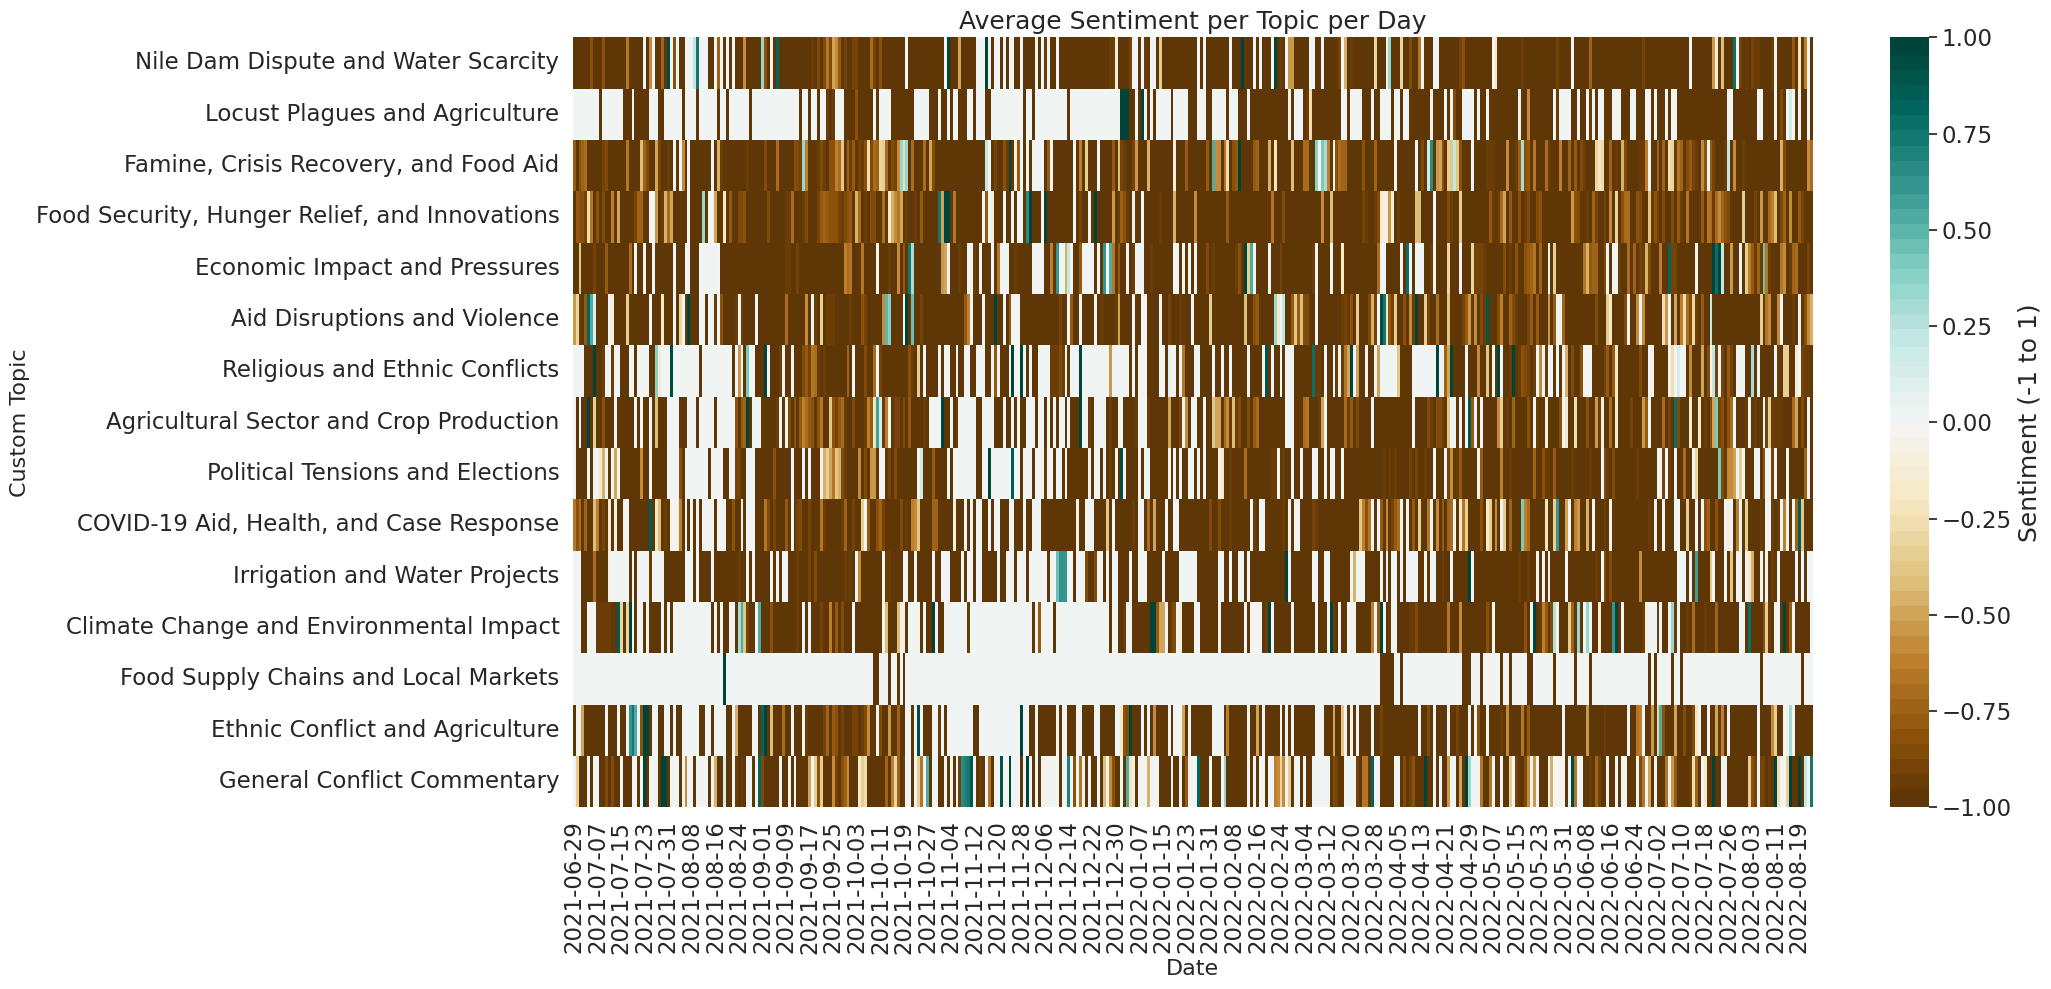

In [32]:
# Check the original 'new_topic_number' column in the sentiment data
print("Checking unique values in 'category_name' column in the original data:")
print(sentiment_data['category_name'].unique())

# Remove rows where 'new_topic_number' is NaN (if any)
sentiment_data = sentiment_data.dropna(subset=['category_name'])

# Ensure 'new_topic_number' is an integer
sentiment_data['category_name'] = sentiment_data['category_name'].astype(int)

# Re-group by date and topic, and calculate the average sentiment per day per topic
sentiment_per_day = sentiment_data.groupby([sentiment_data['created_at'].dt.date, 'category_name'])['sentiment_score'].mean().unstack(fill_value=0)

# Verify if there are still any NaN values in 'new_topic_number'
print("Unique topics after processing:", sentiment_per_day.columns)

# Map custom labels to the topics, using default labels if needed
sentiment_per_day.columns = sentiment_per_day.columns.map(lambda x: custom_labels.get(x, f"Topic {x}"))

# Generate the heatmap with the correct sentiment scale (-1 to 1)
sns.set(font_scale=1.5)
fig = plt.figure(figsize=(20, 10))

# Create the heatmap with the correct color palette and sentiment range
sns.heatmap(sentiment_per_day.T, cmap=sns.color_palette("BrBG", 50), vmin=-1, vmax=1, cbar_kws={'label': 'Sentiment (-1 to 1)'}, center=0)

# Add title and labels
plt.title(f"Average Sentiment per Topic per Day", fontsize=18)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Custom Topic", fontsize=16)

# Save the heatmap as an image
plt.savefig('/content/Stage_3_Per_Topic_sentiment_heatmap.png', dpi=300, bbox_inches='tight')

# Show the heatmap
plt.show()

## Sentiment Score Per Day (All topics)

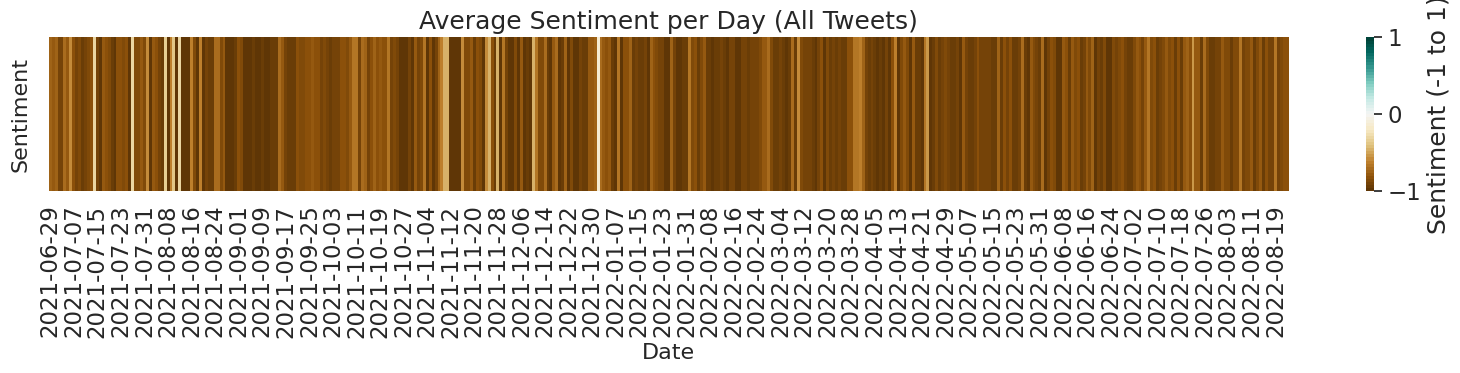

In [33]:
# Assuming 'sentiment_data' is already loaded and cleaned from the previous steps
# Ensure 'created_at' is in datetime format if it's not already
sentiment_data['created_at'] = pd.to_datetime(sentiment_data['created_at'])

#Group by date and calculate the average sentiment per day across all topics
sentiment_per_day = sentiment_data.groupby(sentiment_data['created_at'].dt.date)['sentiment_score'].mean()

# Convert the sentiment per day into a DataFrame (for visualization)
sentiment_per_day_df = sentiment_per_day.to_frame().T  # Transpose for heatmap

# Generate the heatmap with the corrected color scale
sns.set(font_scale=1.5)
fig = plt.figure(figsize=(20, 2))  # Adjusted height for a single-row heatmap

# Create the heatmap with the correct sentiment scale (-1 to 1) and appropriate palette
sns.heatmap(sentiment_per_day_df, cmap=sns.color_palette("BrBG", 50), vmin=-1, vmax=1, cbar_kws={'label': 'Sentiment (-1 to 1)'}, center=0, yticklabels=[''])

# Add title and labels
plt.title(f"Average Sentiment per Day (All Tweets)", fontsize=18)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Sentiment", fontsize=16)  # Manually setting this label

# Save the heatmap as an image
plt.savefig('/content/Stage 3_All_sentiment_heatmap.png', dpi=300, bbox_inches='tight')

# Show the heatmap
plt.show()


<Figure size 640x480 with 0 Axes>